<a href="https://colab.research.google.com/github/deekshdechamma/NLP/blob/main/NLP9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk wordcloud scikit-learn seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
data = {
    "Feedback": [
        "The faculty explains concepts very clearly.",
        "The classroom is clean and comfortable.",
        "Too many assignments every week.",
        "The syllabus is very interesting.",
        "Need more practical sessions.",
        "The teacher is friendly and helpful.",
        "WiFi connection is very slow.",
        "Library has good resources.",
        "The laboratory equipment needs improvement.",
        "The teaching method is excellent.",
        "Classes are too lengthy.",
        "Good interaction between teachers and students.",
        "Need better placement training.",
        "Hostel food quality is poor.",
        "Excellent campus environment.",
        "Need more industry workshops.",
        "Project guidance is very useful.",
        "Exam schedule is stressful.",
        "Sports facilities are good.",
        "Overall learning experience is excellent."
    ],
    "Sentiment": [
        "Positive",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Positive"
    ]
}

df = pd.DataFrame(data)

df.head()

,Feedback,Sentiment
0,The faculty explains concepts very clearly.,Positive
1,The classroom is clean and comfortable.,Positive
2,Too many assignments every week.,Negative
3,The syllabus is very interesting.,Positive
4,Need more practical sessions.,Negative


In [ ]:
df.info()

df.isnull().sum()

df["Sentiment"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Feedback   20 non-null     object
 1   Sentiment  20 non-null     object
dtypes: object(2)
memory usage: 452.0+ bytes


,count
Sentiment,
Positive,11
Negative,9


In [ ]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

df["Clean_Feedback"] = df["Feedback"].apply(clean_text)

df.head()

,Feedback,Sentiment,Clean_Feedback
0,The faculty explains concepts very clearly.,Positive,faculty explains concept clearly
1,The classroom is clean and comfortable.,Positive,classroom clean comfortable
2,Too many assignments every week.,Negative,many assignment every week
3,The syllabus is very interesting.,Positive,syllabus interesting
4,Need more practical sessions.,Negative,need practical session


In [ ]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["Clean_Feedback"])

y = df["Sentiment"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
prediction = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, prediction))

print()

print(classification_report(y_test, prediction))

Accuracy: 0.75

              precision    recall  f1-score   support

    Negative       1.00      0.50      0.67         2
    Positive       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



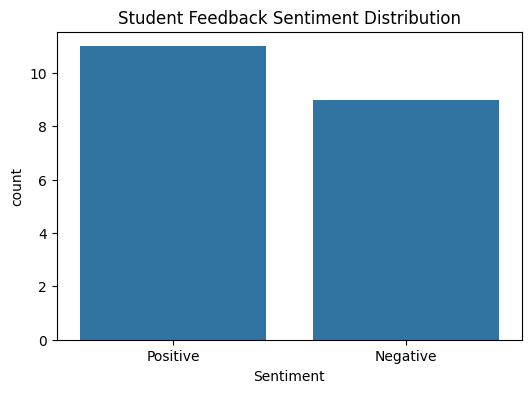

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sentiment", data=df)

plt.title("Student Feedback Sentiment Distribution")

plt.show()

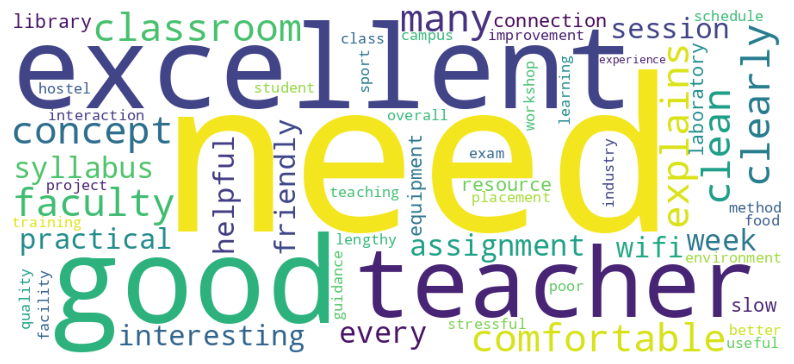

In [ ]:
text = " ".join(df["Clean_Feedback"])

wordcloud = WordCloud(
    width=900,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [ ]:
cv = CountVectorizer(stop_words="english")

word_matrix = cv.fit_transform(df["Clean_Feedback"])

word_count = word_matrix.toarray().sum(axis=0)

words = cv.get_feature_names_out()

frequency = pd.DataFrame({
    "Word": words,
    "Count": word_count
})

frequency = frequency.sort_values(
    by="Count",
    ascending=False
)

print(frequency.head(15))

           Word  Count
33         need      4
20         good      3
13    excellent      3
48      teacher      2
4     classroom      1
3         class      1
0    assignment      1
6       clearly      1
5         clean      1
9    connection      1
7   comfortable      1
10  environment      1
11    equipment      1
12         exam      1
8       concept      1


In [ ]:
feedback = ["Faculty teaches well but practical sessions should be increased."]

clean = clean_text(feedback[0])

vector = vectorizer.transform([clean])

prediction = model.predict(vector)

print("Feedback:", feedback[0])

print("Predicted Sentiment:", prediction[0])

Feedback: Faculty teaches well but practical sessions should be increased.
Predicted Sentiment: Negative
